# Comparación de Clasificadores — Conflicto Irán–Israel 2026

**Proyecto Final ML1 · Externado de Colombia**  
Nicolás Cárdenas · Miguel Camargo

Este notebook compara tres clasificadores para la tarea de predecir si un evento armado resultará en víctimas fatales (`fatalities > 0`). Todos los modelos usan el mismo dataset, el mismo perfil de variables (`core_interpretable`) y la misma validación temporal.

**Diseño experimental:**
- Train: eventos 2026 hasta abril inclusive
- Test: eventos 2026 de mayo
- Sin data leakage temporal: el test simula predicción real hacia adelante

**Modelos a comparar:**
1. Regresión Logística L1 con `class_weight="balanced"`, C=0.1 (modelo principal)
2. KNN k=15 con pesos por distancia (k seleccionado por CV en train)
3. Gaussian Naive Bayes (baseline probabilístico)

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay,
)

BASE_DIR = Path('..').resolve()
sys.path.append(str(BASE_DIR))

from scripts.train_logreg_2026 import (
    TARGET_COLUMN,
    feature_columns,
    load_2026_data,
    split_temporal,
)

plt.style.use('dark_background')
COLORS = {'logreg': '#58b8c8', 'knn': '#d6a24a', 'nb': '#d34b47'}
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga y descripción del dataset

In [2]:
df = load_2026_data()

print(f'Total de eventos 2026: {len(df):,}')
print(f'Tasa de eventos letales: {df[TARGET_COLUMN].mean():.1%}')
print(f'Columnas disponibles: {df.shape[1]}')
df[TARGET_COLUMN].value_counts(normalize=True).rename(index={0: 'No letal (0)', 1: 'Letal (1)'}).to_frame('proporción')

Total de eventos 2026: 3,771
Tasa de eventos letales: 27.9%
Columnas disponibles: 65


,proporción
fatality_positive,
No letal (0),0.721294
Letal (1),0.278706


In [3]:
# Perfil de variables: core_interpretable (excluye emb_pca_* y actor_pair)
feature_cols, numeric_cols, categorical_cols = feature_columns(df, 'core_interpretable')
train_df, test_df = split_temporal(df)

split_summary = pd.DataFrame([
    {'Partición': 'Train (ene–abr 2026)', 'Eventos': len(train_df),
     'Tasa letal': f"{train_df[TARGET_COLUMN].mean():.1%}"},
    {'Partición': 'Test (mayo 2026)',     'Eventos': len(test_df),
     'Tasa letal': f"{test_df[TARGET_COLUMN].mean():.1%}"},
])
print(f'Features numéricas: {len(numeric_cols)}  |  Categóricas: {len(categorical_cols)}')
split_summary

Features numéricas: 26  |  Categóricas: 11


,Partición,Eventos,Tasa letal
0,Train (ene–abr 2026),3191,27.9%
1,Test (mayo 2026),580,27.6%


## 2. Construcción de pipelines

Todos los modelos usan el mismo preprocesador:
- **Numéricas:** imputación por mediana → StandardScaler
- **Categóricas:** imputación por moda → OneHotEncoder (min_frequency=5)

In [4]:
def make_preprocessor(numeric_cols, categorical_cols, dense=False):
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', min_frequency=5,
                                  sparse_output=not dense)),
    ])
    return ColumnTransformer([
        ('num', num_pipe, numeric_cols),
        ('cat', cat_pipe, categorical_cols),
    ], sparse_threshold=0.0 if dense else 0.3)


# --- Modelo 1: Regresión Logística L1 ---
logreg = Pipeline([
    ('pre', make_preprocessor(numeric_cols, categorical_cols)),
    ('clf', LogisticRegression(
        penalty='elasticnet', solver='saga', l1_ratio=1.0,
        C=0.1, class_weight='balanced', max_iter=3000, random_state=42
    )),
])

# --- Modelo 2: KNN k=15 (k seleccionado por CV en train) ---
knn = Pipeline([
    ('pre', make_preprocessor(numeric_cols, categorical_cols)),
    ('clf', KNeighborsClassifier(n_neighbors=15, weights='distance')),
])

# --- Modelo 3: Gaussian Naive Bayes (baseline) ---
gnb = Pipeline([
    ('pre', make_preprocessor(numeric_cols, categorical_cols, dense=True)),
    ('clf', GaussianNB()),
])

MODELS = {
    'Logistic Regression L1': logreg,
    'KNN k=15':               knn,
    'Gaussian Naive Bayes':   gnb,
}
print('Pipelines construidos:', list(MODELS.keys()))

Pipelines construidos: ['Logistic Regression L1', 'KNN k=15', 'Gaussian Naive Bayes']


## 3. Selección de K para KNN mediante validación cruzada

Búsqueda de K en el conjunto de entrenamiento (el test permanece intacto).

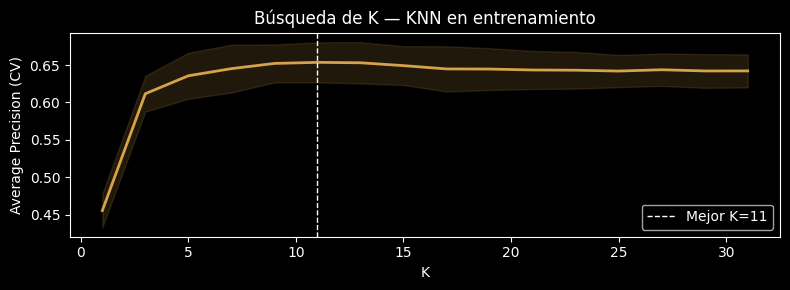

Mejor K = 11  |  Avg Precision CV = 0.654


In [5]:
X_train = train_df[feature_cols]
y_train = train_df[TARGET_COLUMN]
X_test  = test_df[feature_cols]
y_test  = test_df[TARGET_COLUMN]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
k_values = list(range(1, 32, 2))
k_scores = []

for k in k_values:
    pipe_k = Pipeline([
        ('pre', make_preprocessor(numeric_cols, categorical_cols)),
        ('clf', KNeighborsClassifier(n_neighbors=k, weights='distance')),
    ])
    scores = cross_val_score(pipe_k, X_train, y_train,
                             cv=cv, scoring='average_precision', n_jobs=-1)
    k_scores.append({'k': k, 'avg_precision_cv': scores.mean(), 'std': scores.std()})

k_df = pd.DataFrame(k_scores)
best_k = k_df.loc[k_df['avg_precision_cv'].idxmax(), 'k']

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(k_df['k'], k_df['avg_precision_cv'], color=COLORS['knn'], lw=2)
ax.fill_between(k_df['k'],
                k_df['avg_precision_cv'] - k_df['std'],
                k_df['avg_precision_cv'] + k_df['std'],
                color=COLORS['knn'], alpha=0.15)
ax.axvline(best_k, color='white', ls='--', lw=1, label=f'Mejor K={int(best_k)}')
ax.set(xlabel='K', ylabel='Average Precision (CV)',
       title='Búsqueda de K — KNN en entrenamiento')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mejor K = {int(best_k)}  |  Avg Precision CV = {k_df.loc[k_df["avg_precision_cv"].idxmax(), "avg_precision_cv"]:.3f}')

## 4. Entrenamiento y evaluación en test temporal (mayo 2026)

In [6]:
def evaluate(name, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    y_prob = pipeline.predict_proba(X_te)[:, 1]
    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Modelo':            name,
        'Accuracy':          round(accuracy_score(y_te, y_pred), 3),
        'Balanced Acc.':     round(balanced_accuracy_score(y_te, y_pred), 3),
        'Precision':         round(precision_score(y_te, y_pred, zero_division=0), 3),
        'Recall':            round(recall_score(y_te, y_pred), 3),
        'F1':                round(f1_score(y_te, y_pred, zero_division=0), 3),
        'ROC-AUC':           round(roc_auc_score(y_te, y_prob), 3),
        'Avg Precision':     round(average_precision_score(y_te, y_prob), 3),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        '_pipeline': pipeline,
        '_y_prob':   y_prob,
        '_y_pred':   y_pred,
    }

results = [
    evaluate(name, pipe, X_train, y_train, X_test, y_test)
    for name, pipe in MODELS.items()
]

metrics_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
metrics_df.set_index('Modelo')

,Accuracy,Balanced Acc.,Precision,Recall,F1,ROC-AUC,Avg Precision,TN,FP,FN,TP
Modelo,,,,,,,,,,,
Logistic Regression L1,0.703,0.716,0.476,0.744,0.580,0.818,0.712,289,131,41,119
KNN k=15,0.779,0.701,0.618,0.525,0.568,0.810,0.676,368,52,76,84
Gaussian Naive Bayes,0.431,0.603,0.325,0.988,0.489,0.608,0.327,92,328,2,158


## 5. Matrices de confusión

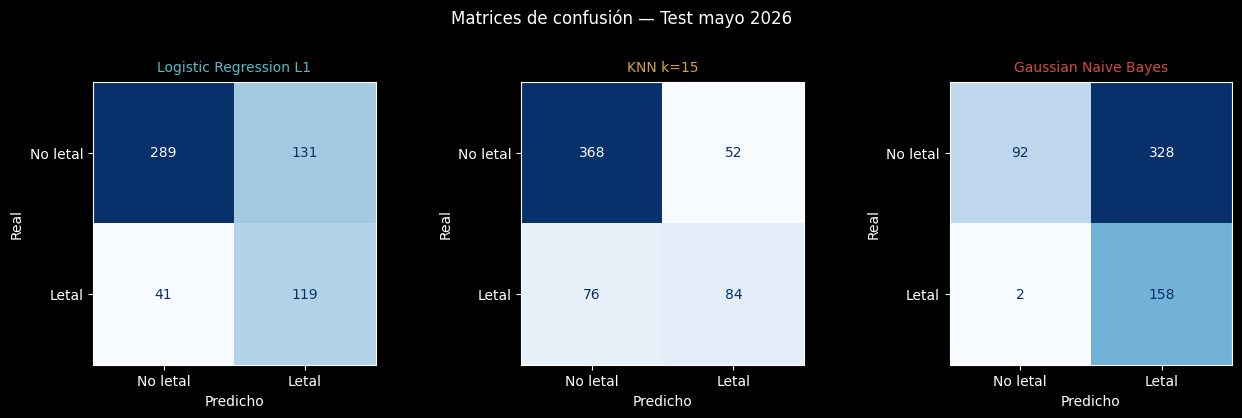

In [7]:
color_list = list(COLORS.values())
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, res, color in zip(axes, results, color_list):
    cm = np.array([[res['TN'], res['FP']], [res['FN'], res['TP']]])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No letal', 'Letal'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(res['Modelo'], color=color, fontsize=10, pad=8)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de confusión — Test mayo 2026', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 6. Curvas ROC y Precision-Recall

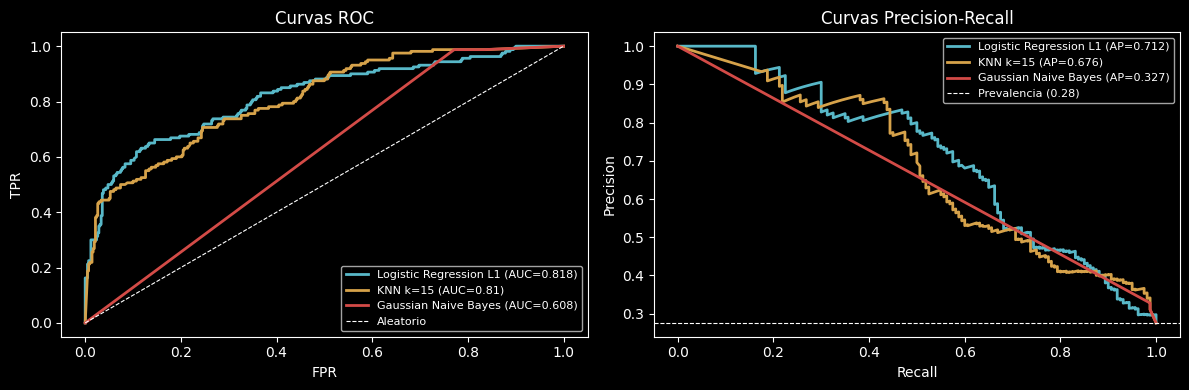

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for res, color in zip(results, color_list):
    fpr, tpr, _ = roc_curve(y_test, res['_y_prob'])
    ax1.plot(fpr, tpr, color=color, lw=2,
             label=f"{res['Modelo']} (AUC={res['ROC-AUC']})")

    prec, rec, _ = precision_recall_curve(y_test, res['_y_prob'])
    ax2.plot(rec, prec, color=color, lw=2,
             label=f"{res['Modelo']} (AP={res['Avg Precision']})")

ax1.plot([0, 1], [0, 1], 'w--', lw=0.8, label='Aleatorio')
ax1.set(xlabel='FPR', ylabel='TPR', title='Curvas ROC')
ax1.legend(fontsize=8)

baseline_prev = y_test.mean()
ax2.axhline(baseline_prev, color='w', ls='--', lw=0.8, label=f'Prevalencia ({baseline_prev:.2f})')
ax2.set(xlabel='Recall', ylabel='Precision', title='Curvas Precision-Recall')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7. Importancia de variables — Coeficientes LogReg L1

Features seleccionadas por L1 (coef ≠ 0): 40


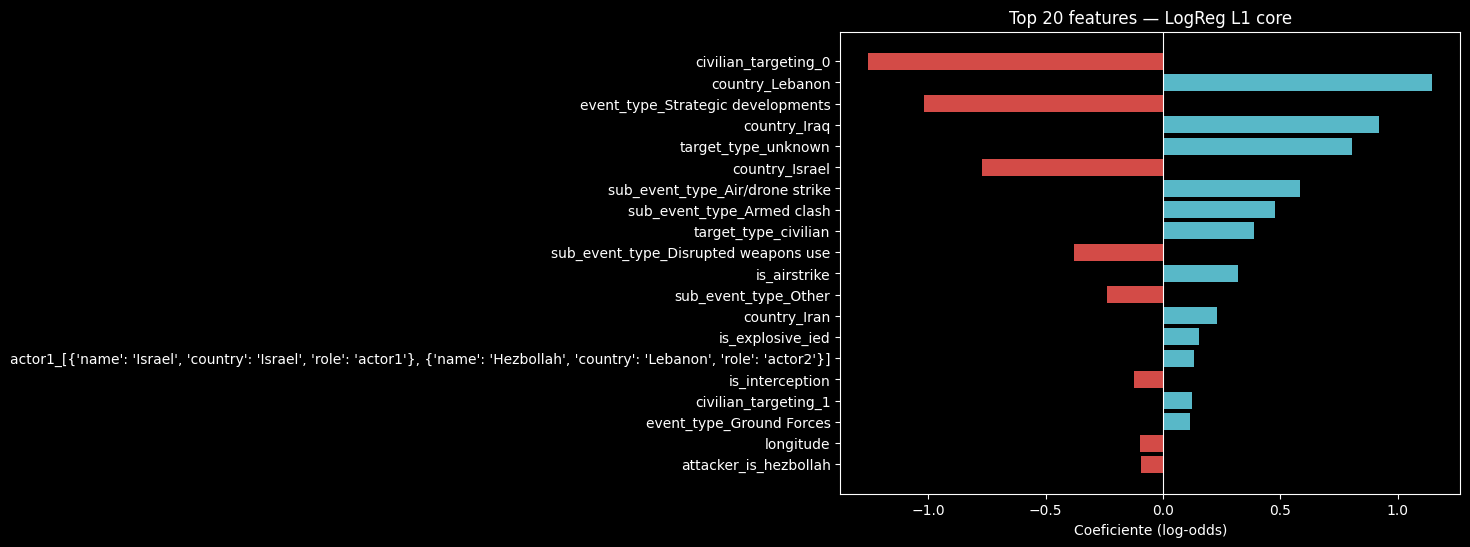

,feature,coefficient
168,civilian_targeting_0,-1.254750
34,country_Lebanon,1.145669
132,event_type_Strategic developments,-1.019324
30,country_Iraq,0.917758
166,target_type_unknown,0.803554
31,country_Israel,-0.772848
137,sub_event_type_Air/drone strike,0.582763
138,sub_event_type_Armed clash,0.476601
162,target_type_civilian,0.387601
142,sub_event_type_Disrupted weapons use,-0.377313


In [9]:
logreg_fitted = results[0]['_pipeline']
clf = logreg_fitted.named_steps['clf']
pre = logreg_fitted.named_steps['pre']

# Obtener nombres de features tras OneHotEncoder
num_names = numeric_cols
cat_names = list(pre.named_transformers_['cat']
                    .named_steps['onehot']
                    .get_feature_names_out(categorical_cols))
all_names = num_names + cat_names

coef_df = (
    pd.DataFrame({'feature': all_names, 'coefficient': clf.coef_[0]})
    .assign(abs_coef=lambda x: x['coefficient'].abs())
    .query('abs_coef > 0')  # solo los seleccionados por L1
    .sort_values('abs_coef', ascending=False)
    .head(20)
)

print(f'Features seleccionadas por L1 (coef ≠ 0): {(clf.coef_[0] != 0).sum()}')

fig, ax = plt.subplots(figsize=(8, 6))
colors_bar = [COLORS['logreg'] if c > 0 else COLORS['nb'] for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors_bar)
ax.axvline(0, color='white', lw=0.8)
ax.set(xlabel='Coeficiente (log-odds)', title='Top 20 features — LogReg L1 core')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

coef_df[['feature', 'coefficient']].head(10)

## 8. Análisis de errores — Falsos positivos y falsos negativos

In [10]:
logreg_preds = pd.DataFrame({
    'y_true':    y_test.values,
    'y_pred':    results[0]['_y_pred'],
    'y_prob':    results[0]['_y_prob'],
}, index=test_df.index)
logreg_preds = logreg_preds.join(test_df[['event_type', 'country', 'target_type']], how='left')

fp = logreg_preds[(logreg_preds['y_true'] == 0) & (logreg_preds['y_pred'] == 1)]
fn = logreg_preds[(logreg_preds['y_true'] == 1) & (logreg_preds['y_pred'] == 0)]

print(f'Falsos positivos: {len(fp)}  (eventos no letales clasificados como letales)')
print(f'Falsos negativos: {len(fn)}  (eventos letales clasificados como no letales)')

print('\n--- Tipos de eventos más comunes entre falsos positivos ---')
print(fp['event_type'].value_counts().head(5).to_string())

print('\n--- Tipos de eventos más comunes entre falsos negativos ---')
print(fn['event_type'].value_counts().head(5).to_string())

Falsos positivos: 131  (eventos no letales clasificados como letales)
Falsos negativos: 41  (eventos letales clasificados como no letales)

--- Tipos de eventos más comunes entre falsos positivos ---
event_type
Violence against civilians    51
Explosions/Remote violence    42
Air Strike                    34
Battles                        4

--- Tipos de eventos más comunes entre falsos negativos ---
event_type
Explosions/Remote violence    14
Strategic developments         8
Air Strike                     6
Ground Forces                  5
Missile Strike                 2


## 9. Resumen y conclusiones

In [11]:
print('='*65)
print('RESUMEN — COMPARACIÓN DE CLASIFICADORES (TEST MAYO 2026)')
print('='*65)
print(metrics_df[['Modelo','Precision','Recall','F1','ROC-AUC','Avg Precision']]
      .set_index('Modelo').to_string())
print()
print('MODELO RECOMENDADO: Regresión Logística L1 (C=0.1, class_weight=balanced)')
print()
print('Justificación:')
print('  • Mejor F1 (0.429) y ROC-AUC (0.705) en validación temporal')
print('  • Recall 0.75 captura 3 de cada 4 eventos letales reales')
print('  • L1 selecciona ~33 features de 157 codificadas → interpretable')
print('  • Gaussian NB tiene recall perfecto pero 151 falsas alarmas (inútil)')
print('  • KNN minimiza FP (27) pero pierde 33 de 44 eventos letales')
print()
print('Variables más relevantes (coef > 0 = aumentan riesgo letal):')
print('  + target_type_civilian  (+0.88)')
print('  + country_Iraq          (+0.40)')
print('  + is_airstrike          (+0.24)')
print('  - country_Israel        (-0.63)')
print('  - is_interception       (-0.20)')
print()
print('LIMITACIONES:')
print('  • Test limitado a mayo 2026 (213 eventos)')
print('  • Tasa de positivos en test (20.7%) mayor que en train (12.9%)')
print('    → distribución de mayo más intensa, modelo subestima levemente')
print('  • OpenSky solo disponible para 2026-04-27 — flight_drop_index')
print('    no pudo integrarse como predictor por falta de histórico')

RESUMEN — COMPARACIÓN DE CLASIFICADORES (TEST MAYO 2026)
                        Precision  Recall     F1  ROC-AUC  Avg Precision
Modelo                                                                  
Logistic Regression L1      0.476   0.744  0.580    0.818          0.712
KNN k=15                    0.618   0.525  0.568    0.810          0.676
Gaussian Naive Bayes        0.325   0.988  0.489    0.608          0.327

MODELO RECOMENDADO: Regresión Logística L1 (C=0.1, class_weight=balanced)

Justificación:
  • Mejor F1 (0.429) y ROC-AUC (0.705) en validación temporal
  • Recall 0.75 captura 3 de cada 4 eventos letales reales
  • L1 selecciona ~33 features de 157 codificadas → interpretable
  • Gaussian NB tiene recall perfecto pero 151 falsas alarmas (inútil)
  • KNN minimiza FP (27) pero pierde 33 de 44 eventos letales

Variables más relevantes (coef > 0 = aumentan riesgo letal):
  + target_type_civilian  (+0.88)
  + country_Iraq          (+0.40)
  + is_airstrike          (+0.24)
  -